## Seminar 4. LSTM, Attention, Transformer
This time we'll learn how to solve a task of machine translation from German to English. For training we will use [Multi30K](https://aclanthology.org/W16-3210/) dataset, which contains around 30k texts describing images, and translations of those descriptions.

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
from torch import nn
import wandb

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
wandb.login()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: fpkh to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


device(type='cuda')

## Data Preparation

[Multi30k](https://arxiv.org/abs/1605.00459) – the most popular academic dataset for testing machine translation models. Let's try testing something out.

All the datasets uploaded to [Hugging Face](https://huggingface.co/datasets) platform could be downloaded in one with: [`load_dataset`](https://huggingface.co/docs/datasets/v2.19.0/en/package_reference/loading_methods#datasets.load_dataset)

In [4]:
from datasets import load_dataset

dataset = load_dataset("bentrevett/multi30k")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

In [5]:
dataset['train'][0]

{'en': 'Two young, White males are outside near many bushes.',
 'de': 'Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.'}

Wrap everything in respective `DataLoader`'s for more convenient iteration.

In [6]:
from torch.utils.data import DataLoader

train_loader = DataLoader(dataset['train'], shuffle=True, batch_size=32)
test_loader = DataLoader(dataset['test'], shuffle=False, batch_size=32)

Mark source and target languages not to get lost

In [7]:
SRC_NAME = 'de'
TRG_NAME = 'en'

### Tokenizer

As the dataset is too small (yeap, 30k lines is now teeny-weeny), we probably won't be able to build sufficiently good tokenizer of our own, so let's just use pretrained one.

Most of the HF tokenizers could be loaded via [AutoTokenizer](https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoTokenizer). BERT (Bidirectional Encoder Representations from Transformers) is an encoder-only transformer architecture, which we'll discuss in details later. `uncased` means that our tokenizer won't consider letter case (will use lowercase actually).

In [8]:
from transformers import AutoTokenizer

tokenizers = {
    'en': AutoTokenizer.from_pretrained('bert-base-uncased'),
    'de': AutoTokenizer.from_pretrained('dbmdz/bert-base-german-uncased')
}

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/433 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [9]:
tokenizers

{'en': BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
 	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
 }
 ),
 'de': BertTokenizerFast(name_or_path='dbmdz/bert-base-german-uncased', vocab_size=31102, model_max_length=512,

In general, there are two types of tokenizers:
1. `Tokenizer` – implemented in Python, because it's more trivial to do.
1. `TokenizerFast` – implemented in Rust using `transformers` library. More often than not 3–5 times faster, than not fast one.

They behave in a same way, so usually (if it is available) `TokenizerFast` is used by default.

In [10]:
tokenizers['en']

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

You could implicitly import any tipe of the available tokenizers.

In [11]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokenizer

BertTokenizer(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

If you call the tokenizer on text, it will return an object of the [BatchEncoding](https://huggingface.co/docs/transformers/v4.45.1/en/main_classes/tokenizer#transformers.BatchEncoding) class.

In [12]:
encoded = tokenizers['en']('Random text to encode')
type(encoded)

transformers.tokenization_utils_base.BatchEncoding

In [13]:
encoded.tokens(), encoded.word_ids()

(['[CLS]', 'random', 'text', 'to', 'en', '##code', '[SEP]'],
 [None, 0, 1, 2, 3, 3, None])

`[CLS]` – *beginning-of-sequence* token (alternative to `[BOS]`).
`[SEP]` – *end-of-sequence* token (alternative to `[EOS]`)

In [14]:
encoded

{'input_ids': [101, 6721, 3793, 2000, 4372, 16044, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

`input_ids` – token indices.
`attention_mask` – mask in which we set all the non-padding tokens to be 1. We need it in order to tokenize batch of the texts of different length using padding.
`token_type_ids` – shows to which part of the text each token is related. Used in some specific training tasks.

In [15]:
encoded = tokenizers['en'](
    ['First text to encode', 'Second text'],
    padding=True,        # add paddings to the short texts
    max_length=3,        # limit the maximal sequence length
    truncation=True,     # truncate up to the maximal length
    return_token_type_ids=False,
    return_tensors='pt'  # return PyTorch tensors
)
encoded

{'input_ids': tensor([[ 101, 2034,  102],
        [ 101, 2117,  102]]), 'attention_mask': tensor([[1, 1, 1],
        [1, 1, 1]])}

We could get only tokens if other info is irrelevant.

In [16]:
encoded = tokenizers['en'].encode('Random text to encode')
encoded

[101, 6721, 3793, 2000, 4372, 16044, 102]

For decoding tokens back to text we could use `.decode` (`.batch_decode` for batch of the texts).

In [17]:
tokenizers['en'].decode(encoded)

'[CLS] random text to encode [SEP]'

In [18]:
tokenizers['en'].decode(encoded, skip_special_tokens=True)

'random text to encode'

Let's check distribution of text lengths in order to limit generation.

In [19]:
de_lens = [len(tokenizers['de'].encode(text)) for text in dataset['train']['de']]
en_lens = [len(tokenizers['en'].encode(text)) for text in dataset['train']['en']]

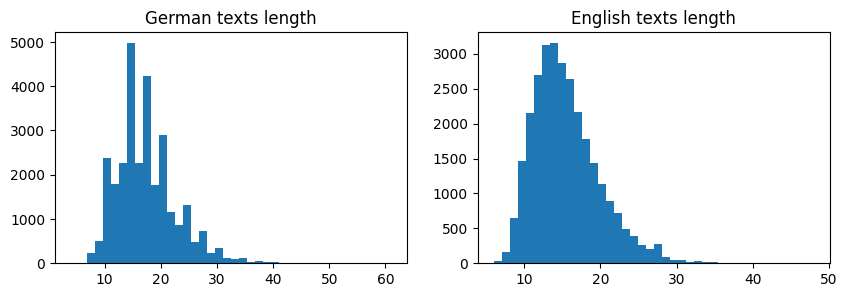

In [20]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.hist(de_lens, bins=40)
plt.title('German texts length')

plt.subplot(1, 2, 2)
plt.hist(en_lens, bins=40)
plt.title('English texts length')

plt.show()

Let us fix a length of approximately 32 tokens for the most texts. We'll use it later.

In [21]:
MAX_LENGTH = 32

## Bilingual Evaluation Understudy (BLEU) Algorithm

$$
BLEU(\hat{Y}, Y) = BP(\hat{Y}, Y) \cdot \exp\left(\sum_{n=1}^N w_n \ln p_n(\hat{Y}, Y) \right),
$$
where $p_n(\hat{Y}, Y)$ – precision, $n$ – size of the n-gram.

__Brevity penalty__ ~~spanks hard~~ penalizes the model for the short answers.
$$
BP(\hat{Y}, Y) = \exp\bigg( -\left[\frac{\sum_{i=1}^m|y_i|}{\sum_{i=1}^m|\hat{y}_i|} - 1\right]_+ \bigg)
$$

There are plenty of BLEU implementations: [moses](https://github.com/moses-smt/mosesdecoder/blob/master/scripts/generic/multi-bleu.perl), [nltk](https://www.nltk.org/_modules/nltk/translate/bleu_score.html), [sacrebleu](https://pypi.org/project/sacrebleu/), [huggingface](https://huggingface.co/spaces/evaluate-metric/bleu). In practice, they differ by means of text tokenization and smoothing, and give different results for the same data. Hence, it is __extremely crucial__ to use the same implementations of BLEU throughout the testing. We'll use huggingface's version, minimizing additional effort.

In [24]:
import evaluate
bleu_score = evaluate.load('bleu')

## LSTM

Recurrent neural network for Seq2Seq looks like this.
[(see "Как выглядит схема?")](https://www.youtube.com/watch?v=MSltI0iYlvA)

<img src="https://i.postimg.cc/xTvrvhJc/rnn-seq2seq.png" alt="drawing" width="700"/>

In our implementation we'll make Encoder bidirectional for it to consider more context.
Due to the fact, that there is a bottleneck between the encoder and the decoder, we'll probably get not to high quality of generation.

In [43]:
class Seq2SeqLSTM(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(src_vocab_size, hidden_size)
        # bidirectional LSTM Encoder
        self.encoder = nn.LSTM(hidden_size, hidden_size, bidirectional=True, batch_first=True)
        # usual LSTM Decoder
        self.decoder = nn.LSTM(hidden_size, hidden_size, bidirectional=False, batch_first=True)

        self.h_proj = nn.Linear(2 * hidden_size, hidden_size)
        self.c_proj = nn.Linear(2 * hidden_size, hidden_size)

        self.out_proj = nn.Linear(hidden_size, trg_vocab_size)

    def encode(self, input_ids, *args, **kwargs):
        bs = len(input_ids)

        input_embedded = self.embedding(input_ids)
        _, (h_enc, c_enc) = self.encoder(input_embedded)

        # h_enc: [2, bs, hidden_size]
        # first dimension – number of layers
        h_enc = h_enc.permute(1, 0, 2).reshape(1, bs, -1) # [1, batch, 2 * hidden_size]
        c_enc = c_enc.permute(1, 0, 2).reshape(1, bs, -1) # [1, batch, 2 * hidden_size]

        h_enc = self.h_proj(h_enc)
        c_enc = self.c_proj(c_enc)

        return h_enc, c_enc

    def forward(self, input_ids, output_ids, *args, **kwargs):
        h_enc, c_enc = self.encode(input_ids)

        output_embedded = self.embedding(output_ids)
        dec_output, _ = self.decoder(output_embedded, (h_enc, c_enc))

        logits = self.out_proj(dec_output)
        return logits

    @torch.inference_mode()
    def generate(self, input_ids, *args, max_length=MAX_LENGTH, **kwargs):
        bs = len(input_ids)

        h_enc, c_enc = self.encode(input_ids)
        output_ids = [torch.full((bs,), tokenizers[TRG_NAME].cls_token_id, device=input_ids.device)]

        state = (h_enc, c_enc)

        for i in range(max_length):
            dec_input = self.embedding(output_ids[-1].unsqueeze(-1))
            dec_output, state = self.decoder(dec_input, state)
            logits = self.out_proj(dec_output)

            output_ids.append(logits.argmax(-1).squeeze(-1))

        output_ids = torch.stack(output_ids).T
        return output_ids

Support functions for training and validation. `clean_text` is used to clean up generated texts. When an entire batch is generated, there may be a bunch of junk tokens after the `[SEP]` token. These need to be removed.

In [44]:
def clean_text(texts):
    """
    Remove all tokens (if present) before [CLS] and after [SEP]
    """
    new_texts = []
    for text in texts:
        cls_pos = text.find('[CLS]')
        text = text[cls_pos + len('[CLS] '):]

        sep_pos = text.find(' [SEP]')
        if sep_pos != -1:
            text = text[:sep_pos]

        new_texts.append(text)

    return new_texts

In [45]:
def tokenize(batch):
    """
    Tokenize every input and output sequence.
    Prune all the texts up to maximal length.
    """
    tokenizer_kwargs = dict(
        padding=True,
        max_length=MAX_LENGTH,
        truncation=True,
        return_tensors='pt'
    )
    input = tokenizers[SRC_NAME](batch[SRC_NAME], **tokenizer_kwargs).to(device)
    output = tokenizers[TRG_NAME](batch[TRG_NAME], **tokenizer_kwargs).to(device)

    return input, output

def train(model, dataloader, optimizer):
    """
    Fit the model on the whole dataset via the dataloader.
    """

    model.train()
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizers[TRG_NAME].pad_token_id)

    for batch in dataloader:
        input, output = tokenize(batch)

        logits = model(
            input['input_ids'],
            output['input_ids'],
            input['attention_mask'],
            output['attention_mask']
        )

        # NB! shift our predictions in such a way, that for each current token we predict
        # the subsequent one and compare it with the actual following token
        shifted_logits = logits[:, :-1]
        shifted_targets = output['input_ids'][:, 1:]

        # juggle around shapes of the logit, because in the CrossEntropyLoss
        # predictions of the classes must be the second shape
        loss = criterion(shifted_logits.permute(0, 2, 1), shifted_targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Calculate batch-accuracy, ignoring the padding tookens
        accuracy = (shifted_logits.argmax(-1) == shifted_targets).float()
        accuracy = accuracy[shifted_targets != tokenizers[TRG_NAME].pad_token_id].mean().item()

        wandb.log({
            "train_loss": loss.item(),
            "train_accuracy": accuracy
        })


@torch.inference_mode()
def evaluate(model, dataloader):
    """
    Fits the model on the whole dataset via the dataloader.
    """

    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=tokenizers[TRG_NAME].pad_token_id)

    accuracies = []
    losses = []
    text_predictions = []
    text_references = []
    for batch in dataloader:
        input, output = tokenize(batch)

        logits = model(
            input['input_ids'],
            output['input_ids'],
            input['attention_mask'],
            output['attention_mask']
        )

        shifted_logits = logits[:, :-1]
        shifted_targets = output['input_ids'][:, 1:]

        # NB! shift our predictions in such a way, that for each current token we predict
        # the subsequent one and compare it with the actual following token
        loss = criterion(shifted_logits.permute(0, 2, 1), shifted_targets)
        losses.append(loss.item())

        # Iiiits kinda not honest to do on the validation set, because numbers of tokens
        # may vary for different batches, hence batches must be re-weighted accordingly.
        # Yet, we need accuracy only to track the fitting progress, so whatever.
        tokens = shifted_logits.argmax(-1)
        accuracy = (tokens == shifted_targets).float()
        accuracy = accuracy[shifted_targets != tokenizers[TRG_NAME].pad_token_id].mean().item()
        accuracies.append(accuracy)

        gen_ids = model.generate(input['input_ids'], input['attention_mask'])
        text_predictions.extend(clean_text(tokenizers[TRG_NAME].batch_decode(gen_ids)))
        text_references.extend(tokenizers[TRG_NAME].batch_decode(output['input_ids'], skip_special_tokens=True))

    bleu_results = bleu_score.compute(predictions=text_predictions, references=text_references)

    wandb.log({
        "test_loss": np.mean(losses),
        "test_accuracy": np.mean(accuracies),
        "BLEU": bleu_results['bleu']
    })

Initialize the model with the optimizer and fit it.

In [50]:
model = Seq2SeqLSTM(len(tokenizers[SRC_NAME]), len(tokenizers[TRG_NAME]), 128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print('All parameters:', sum([torch.numel(p) for p in model.parameters()]))
print('Non-embedding parameters:',
      sum([torch.numel(p) for p in model.parameters()]) - \
      torch.numel(model.embedding.weight) - \
      torch.numel(model.out_proj.weight)
)

All parameters: 8380474
Non-embedding parameters: 492602


In [51]:
wandb.init(project="seminar3", name="lstm")

BLEU,▁██
test_accuracy,▁▅█
test_loss,█▄▁
train_accuracy,▁▄▅▅▅▆▆▆▆▆▆▆▆▆▇▆▇▇▇▆▇▆▆▆▇▆▇▇▇▇▇▇▇▇██████
train_loss,█▆▆▄▃▃▂▂▂▂▃▂▂▂▂▂▂▂▂▂▂▂▁▂▂▁▁▂▂▁▂▁▁▁▁▁▁▂▁▁
BLEU,0.02544
test_accuracy,0.29543
test_loss,4.5058
train_accuracy,0.31868
train_loss,4.18348


In [52]:
from tqdm.notebook import tqdm

for e in tqdm(range(10), "Epochs"):
    train(model, train_loader, optimizer)
    evaluate(model, test_loader)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

In [53]:
torch.save(model.state_dict(), 'weights/lstm.pt')
# model.load_state_dict(torch.load('weights/lstm.pt', map_location=device))

Resulting BLEU value on the test dataset: __0.152__.

Let's check the actual translations.

In [54]:
model.eval();

In [55]:
batch = next(iter(test_loader))
input, output = tokenize(batch)

In [56]:
with torch.inference_mode():
    gen_ids = model.generate(input['input_ids'])
    preds = clean_text(tokenizers[TRG_NAME].batch_decode(gen_ids))

In [57]:
preds[:5]

['a man in a red shirt is standing on a street.',
 'a young man is standing on a street with a large building.',
 'a girl in a red shirt is sitting on a street.',
 'three people in a red shirt and a red shirt is sitting on a street.',
 'people are sitting on a street.']

In [58]:
batch['de'][:5]

['Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.',
 'Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.',
 'Ein Mädchen in einem Karateanzug bricht ein Brett mit einem Tritt.',
 'Fünf Leute in Winterjacken und mit Helmen stehen im Schnee mit Schneemobilen im Hintergrund.',
 'Leute Reparieren das Dach eines Hauses.']

In [59]:
batch['en'][:5]

['A man in an orange hat starring at something.',
 'A Boston Terrier is running on lush green grass in front of a white fence.',
 'A girl in karate uniform breaking a stick with a front kick.',
 'Five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.',
 'People are fixing the roof of a house.']

We shall see, that the translations look gramatically correct and all the acting characters were transfered correctly. Yet, almost all the actions do not correspond to the actual translation.

Let's check, whether the Doctor ~~D~~ Transformer will solve our problem.

### To sum up
1. We've downloaded the dataset and the tokenizers.
2. We've selected the metric for evaluation of quality of generation.
3. We've fitted the LSTM as the baseline.

## Transformer

The core idea of the transformer architecture is that you need some attention {mechanism}. Hence, the tokens could share some information among each other preserving only the relevant info.

<img src="https://i.postimg.cc/vTGK3H6T/transformer.png" alt="drawing" width="400"/>

In [69]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, hidden_size,
                 num_encoder_layers=1, num_decoder_layers=1, max_len=MAX_LENGTH):
        super().__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(src_vocab_size, hidden_size)
        self.positional_embedding = nn.Embedding(max_len, hidden_size)
        self.transformer = nn.Transformer(
            d_model=hidden_size, nhead=8,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=4 * hidden_size,
            batch_first=True
        )
        self.out_proj = nn.Linear(hidden_size, trg_vocab_size)

    def encode(self, input_ids, attention_mask=None):
        T = input_ids.size(1)
        pos = torch.arange(T, device=input_ids.device) % self.positional_embedding.num_embeddings
        x = self.embedding(input_ids) + self.positional_embedding(pos)[None, :]
        return self.transformer.encoder(
            x,
            src_key_padding_mask=(~attention_mask.bool()) if attention_mask is not None else None
        )

    def decode(self, output_ids, encoded_input, src_attention_mask=None, trg_attention_mask=None):
        T = output_ids.size(1)
        pos = torch.arange(T, device=output_ids.device) % self.positional_embedding.num_embeddings
        y = self.embedding(output_ids) + self.positional_embedding(pos)[None, :]
        tgt_mask = self.transformer.generate_square_subsequent_mask(T).to(output_ids.device)
        dec = self.transformer.decoder(
            y, encoded_input,
            memory_key_padding_mask=(~src_attention_mask.bool()) if src_attention_mask is not None else None,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=(~trg_attention_mask.bool()) if trg_attention_mask is not None else None
        )
        return self.out_proj(dec)

    def forward(self, input_ids, output_ids, src_attention_mask, trg_attention_mask):
        mem = self.encode(input_ids, src_attention_mask)
        return self.decode(output_ids, mem, src_attention_mask, trg_attention_mask)

    @torch.no_grad()
    def generate(self, input_ids, src_attention_mask=None, max_length=MAX_LENGTH):
        """
        Greedy decoding with:
        - automatic construction of src_attention_mask if missing
        - early stop on [SEP]
        - position index wrap-around safety
        """
        device = input_ids.device
        bs = input_ids.size(0)

        # build mask automatically if not provided
        if src_attention_mask is None:
            try:
                src_pad = tokenizers[SRC_NAME].pad_token_id
            except Exception:
                src_pad = 0  # fallback if pad is 0
            src_attention_mask = input_ids.ne(src_pad)

        mem = self.encode(input_ids, src_attention_mask)

        cls_id = tokenizers[TRG_NAME].cls_token_id
        sep_id = tokenizers[TRG_NAME].sep_token_id
        pad_id = tokenizers[TRG_NAME].pad_token_id

        out = torch.full((bs, 1), cls_id, dtype=torch.long, device=device)
        finished = torch.zeros(bs, dtype=torch.bool, device=device)

        for _ in range(min(max_length, self.max_len - 1)):
            tgt_attn = out.ne(pad_id)
            logits = self.decode(out, mem, src_attention_mask, tgt_attn)
            next_tok = logits[:, -1, :].argmax(dim=-1)

            # freeze already finished sequences at [SEP]
            next_tok = torch.where(finished, torch.full_like(next_tok, sep_id), next_tok)
            out = torch.cat([out, next_tok.unsqueeze(1)], dim=1)

            finished |= next_tok.eq(sep_id)
            if finished.all():
                break

        return out


Fitting time. Take a Transformer with a __single__ layer of the same size, as in the LSTM. Hence, the comparison will be more fair.

In [70]:
model = Seq2SeqTransformer(len(tokenizers[SRC_NAME]), len(tokenizers[TRG_NAME]), 128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print('All parameters:', sum([torch.numel(p) for p in model.parameters()]))
print('Non-embedding parameters:',
      sum([torch.numel(p) for p in model.parameters()]) - \
      torch.numel(model.embedding.weight) - \
      torch.numel(model.out_proj.weight)
)

All parameters: 8385850
Non-embedding parameters: 497978


In [71]:
wandb.init(project="seminar3", name="1layer_transformer")

BLEU,▁▃▄▅▅▆▆▇▇█
test_accuracy,▁▃▅▅▆▆▇▇██
test_loss,█▆▅▄▃▂▂▂▁▁
train_accuracy,▁▂▃▃▄▅▅▄▆▅▅▅▆▆▅▅▅▆▆▇▆▇▇▆▆▇▇▆▆▇▇▆█▇▇▆▇█▇▇
train_loss,█▇▆▆▅▄▄▃▃▅▄▃▃▃▃▃▃▃▃▂▃▂▃▃▂▁▂▂▃▂▃▁▁▂▁▁▂▁▂▂
BLEU,0.22829
test_accuracy,0.53968
test_loss,2.8269
train_accuracy,0.54098
train_loss,2.52575


In [75]:
for e in tqdm(range(10)):
    train(model, train_loader, optimizer)
    evaluate(model, test_loader)

  0%|          | 0/10 [00:00<?, ?it/s]

In [76]:
torch.save(model.state_dict(), 'weights/1layer_transformer.pt')
# model.load_state_dict(torch.load('weights/1layer_transformer.pt', map_location=device))


Resulting BLEU for this Transformer on the test dataset: __0.32__.
That's __significantly__ better, than 0.152 which LSTM had!

Using the same examples we can see that the model transfers __much__ more information.

In [77]:
model.eval();

In [78]:
batch = next(iter(test_loader))
input, output = tokenize(batch)

In [79]:
with torch.inference_mode():
    gen_ids = model.generate(input['input_ids'])
    preds = clean_text(tokenizers[TRG_NAME].batch_decode(gen_ids))

In [80]:
preds[:5]

['a man in an orange hat is working on the ground.',
 'a large stick is running over a green grass in front of a white car.',
 'a girl in a room is sitting in a room with a restaurant.',
 'five people in winter clothing in red and blue snow with snow in the background.',
 'people are working on a window of a store.']

In [81]:
batch['de'][:5]

['Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.',
 'Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.',
 'Ein Mädchen in einem Karateanzug bricht ein Brett mit einem Tritt.',
 'Fünf Leute in Winterjacken und mit Helmen stehen im Schnee mit Schneemobilen im Hintergrund.',
 'Leute Reparieren das Dach eines Hauses.']

In [82]:
batch['en'][:5]

['A man in an orange hat starring at something.',
 'A Boston Terrier is running on lush green grass in front of a white fence.',
 'A girl in karate uniform breaking a stick with a front kick.',
 'Five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.',
 'People are fixing the roof of a house.']

## Attention mechanism visualization

As our transformer has only a single layer, it has only one Cross Attention layer. We could see on different examples, which weights we get for this attention layer.

In [83]:
# Load pretrained model

model = Seq2SeqTransformer(len(tokenizers[SRC_NAME]), len(tokenizers[TRG_NAME]), 128).to(device)
model.load_state_dict(torch.load('weights/1layer_transformer.pt', map_location=torch.device('cpu')))
model.eval();

In this model, it is not so easy to access the attention weights, so we will have to improvise. We will redefine the `_mha_block` function by changing the `need_weights` parameter from `False` to `True`. This is necessary for this layer to return attention weights. After that, we will launch a hook so that we can get the outputs of the `multihead_attn` layer after running the model.


In [84]:
from functools import partial

def _mha_block(self, x, mem, attn_mask, key_padding_mask, is_causal=False):
    x = self.multihead_attn(x, mem, mem,
                            attn_mask=attn_mask,
                            key_padding_mask=key_padding_mask,
                            is_causal=is_causal,
                            need_weights=True)[0]
    return self.dropout2(x)

model.transformer.decoder.layers[0]._mha_block = partial(_mha_block, model.transformer.decoder.layers[0])

In [85]:
attention_weights = {}
def get_attention_weights(name):
    def hook(model, input, output):
        attention_weights[name] = output[1].cpu()
    return hook

model.transformer.decoder.layers[0].multihead_attn.register_forward_hook(get_attention_weights('multihead_attn'))

Let's run everything and see if the attention weights from Cross Attention really ended up in `attention_weights[‘multihead_attn’]`.

In [86]:
with torch.inference_mode():
    logits = model(
        input['input_ids'], output['input_ids'],
        input['attention_mask'], output['attention_mask']
    )

att_weights = attention_weights['multihead_attn']
att_weights.shape, att_weights[0].sum(-1)

(torch.Size([32, 31, 32]),
 tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000]))

Now let's display the resulting matrices for a few short examples. The tokens of the target language (English) are arranged vertically, and the input sequence (German) is arranged horizontally. It is clear that for each English token (row), the model looks at the next token in the German text. This is how it should be, because the model's task is to predict the next token.

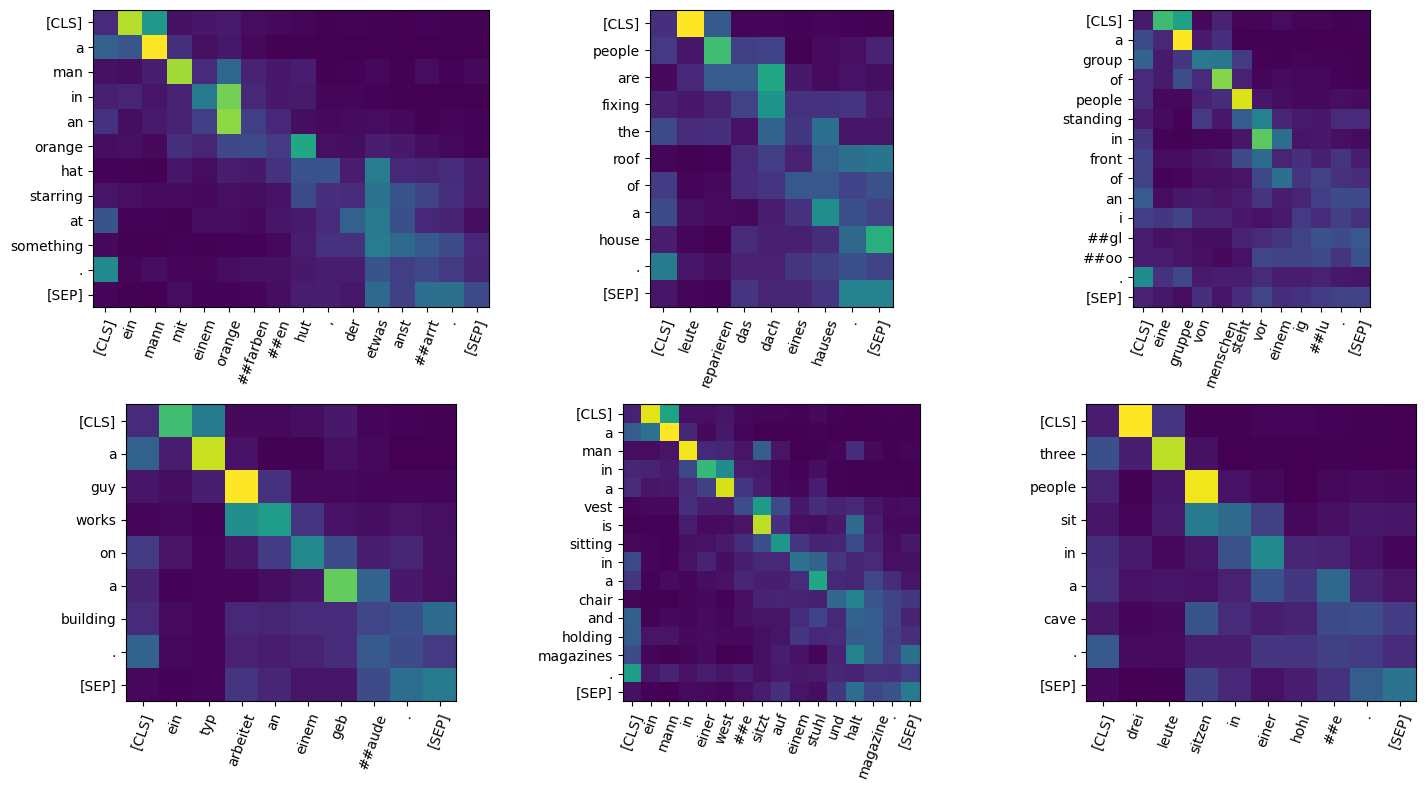

In [87]:
idxs = [0, 4, 6, 8, 9, 14]
n = len(idxs)

plt.figure(figsize=(15, 8))

for i, idx in enumerate(idxs):
    plt.subplot(2, n // 2, i + 1)
    src_len = input['attention_mask'][idx].sum().item()
    trg_len = output['attention_mask'][idx].sum().item()

    src_tokens = tokenizers[SRC_NAME].convert_ids_to_tokens(input['input_ids'][idx])[:src_len]
    trg_tokens = tokenizers[TRG_NAME].convert_ids_to_tokens(output['input_ids'][idx])[:trg_len]

    plt.imshow(att_weights[idx, :trg_len, :src_len])
    plt.xticks(np.arange(src_len), src_tokens, rotation=70)
    plt.yticks(np.arange(trg_len), trg_tokens)

plt.tight_layout()

## The Importance of Cross Attention

We have already mentioned that the main problem with recurrent models for Seq2seq is that a bottleneck arises between the Encoder and Decoder, causing some information to be lost. Cross Attention in Transformer is designed to solve this problem, and from the example above, we can see that it learns something very reasonable.

However, it should be noted that Transformer also has Self-Attention, which should also improve the model.  Perhaps Transformer is only good because of it, and Cross Attention only helps a little? Let's check how Cross Attention affects the result by removing it from the model. We will create an artificial bottleneck by forcing the decoder to look only at the output of the zero ([CLS]) token.

In [88]:
class Seq2SeqTransformerNoCA(Seq2SeqTransformer):
    """
    Same as Seq2SeqTransformer.
    Change only decoding.
    """

    def __init__(self, src_vocab_size, trg_vocab_size, hidden_size,
                 num_encoder_layers=1, num_decoder_layers=1, max_len=MAX_LENGTH):
        super().__init__(
            src_vocab_size, trg_vocab_size, hidden_size,
            num_encoder_layers=1, num_decoder_layers=1, max_len=MAX_LENGTH
        )

    def decode(self, output_ids, encoded_input, src_attention_mask=None, trg_attention_mask=None):
        trg_seq_len = output_ids.shape[1]

        output_embedded = self.embedding(output_ids)
        output_embedded += self.positional_embedding(torch.arange(trg_seq_len, device=output_ids.device))[None, :]

        trg_mask = self.transformer.generate_square_subsequent_mask(trg_seq_len).to(output_ids.device)

        # От всего выхода Encoder'a оставляем только нулевой токен
        # From all the output leave only the token with id 0
        dec_output = self.transformer.decoder(
            output_embedded,
            encoded_input[:, :1],
            tgt_mask=trg_mask,
            tgt_key_padding_mask=~trg_attention_mask.bool() if trg_attention_mask is not None else None
        )

        logits = self.out_proj(dec_output)

        return logits

Fitting the model without Cross Attention and evaluating the quality.

In [89]:
model = Seq2SeqTransformerNoCA(
    len(tokenizers[SRC_NAME]),
    len(tokenizers[TRG_NAME]),
    hidden_size=128,
    num_encoder_layers=1,
    num_decoder_layers=1
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [90]:
wandb.init(project="seminar3", name="1layer_transformer_no_ca")

BLEU,▁▂▃▄▅▆▆▇▇█
test_accuracy,▁▂▄▅▆▆▇▇██
test_loss,█▇▅▄▄▃▂▂▁▁
train_accuracy,▁▂▄▃▄▄▄▅▅▆▆▆▆▆▅▅▆▅▆▆▆▅▆▇▆▆▆▇▆▅▇▆▆█▇▇█▇▇█
train_loss,██▇▅▅▅▅▄▄▅▄▄▄▄▄▄▃▃▃▃▂▂▂▃▂▂▂▂▂▂▂▂▃▂▁▁▁▁▁▂
BLEU,0.23126
test_accuracy,0.5405
test_loss,2.77473
train_accuracy,0.576
train_loss,2.21687


In [91]:
for e in tqdm(range(10), "Epochs"):
    train(model, train_loader, optimizer)
    evaluate(model, test_loader)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:6041: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


We get a BLEU score of __0.19__. This is a very significant drop in quality.
So the problem with recurrent models really is a bottleneck!

## More layers

Thanks to skip connections, Transformers scale very well. Let's increase the number of layers to 4 and see if this improves the model.

<img src="https://i.postimg.cc/SRzG6BgR/more-layers.png" alt="drawing" width="500"/>

In [92]:
model = Seq2SeqTransformer(
    len(tokenizers[SRC_NAME]),
    len(tokenizers[TRG_NAME]),
    hidden_size=128,
    num_encoder_layers=4,
    num_decoder_layers=4
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print('All parameters:', sum([torch.numel(p) for p in model.parameters()]))
print('Non-embedding parameters:',
      sum([torch.numel(p) for p in model.parameters()]) - \
      torch.numel(model.embedding.weight) - \
      torch.numel(model.out_proj.weight)
)

All parameters: 9774394
Non-embedding parameters: 1886522


In [93]:
wandb.init(project="seminar3", name="4layers_transformer")

BLEU,▁▃▄▅▅▆▇▇▇█
test_accuracy,▁▃▅▅▆▆▇▇██
test_loss,█▆▄▄▃▂▂▂▁▁
train_accuracy,▁▁▃▃▃▅▄▅▅▅▆▆▆▅▆▄▆▆▅▇▅▅█▆▆▅▅▇▇▅██▇▇▇▇▆▇▇█
train_loss,█▅▄▄▃▃▃▃▃▃▃▂▂▂▃▂▂▂▂▁▂▂▂▂▂▁▂▂▁▂▂▂▁▂▂▂▁▂▁▁
BLEU,0.12946
test_accuracy,0.45667
test_loss,3.26501
train_accuracy,0.49505
train_loss,3.02584


In [94]:
for e in tqdm(range(10), "Epochs"):
    train(model, train_loader, optimizer)
    evaluate(model, test_loader)

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

In [95]:
torch.save(model.state_dict(), 'weights/4layer_transformer.pt')
# model.load_state_dict(torch.load('weights/4layer_transformer.pt', map_location=device))


We obtained a BLEU score of __0.342__. This is slightly higher than the single-layer model. If the sequences were longer, the increment would be greater.

In [96]:
model.eval();

In [97]:
batch = next(iter(test_loader))
input, output = tokenize(batch)

In [98]:
with torch.inference_mode():
    gen_ids = model.generate(input['input_ids'], input['attention_mask'])
    preds = clean_text(tokenizers[TRG_NAME].batch_decode(gen_ids))

In [99]:
preds[:5]

['a man with an orange hat is talking to something.',
 'a couple is running across the green field of a green and white grass.',
 'a girl in a karate is getting a car with a toy.',
 'five people in winter hats and wearing a helmet are standing in the snow with snow in the snow.',
 'people are enjoying a window of a train.']

In [100]:
batch['de'][:5]

['Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.',
 'Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.',
 'Ein Mädchen in einem Karateanzug bricht ein Brett mit einem Tritt.',
 'Fünf Leute in Winterjacken und mit Helmen stehen im Schnee mit Schneemobilen im Hintergrund.',
 'Leute Reparieren das Dach eines Hauses.']

In [101]:
batch['en'][:5]

['A man in an orange hat starring at something.',
 'A Boston Terrier is running on lush green grass in front of a white fence.',
 'A girl in karate uniform breaking a stick with a front kick.',
 'Five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.',
 'People are fixing the roof of a house.']

## Beam Search

Finally, let's try the Beam Search sampling method. It increases the probability of the output sequence as it keeps a few most likely branches of candidates while discarding less likely ones. Beam Search is a compromise between greedy sampling and exhaustive search.

In [102]:
@torch.inference_mode()
def beam_search(input_encoded, model, beam_width=5, max_len=MAX_LENGTH, alpha=0.6):
    """
    For Encoder's output for a single examples
    generates a translation using Beam Search
    with beam of size beam_width
    """
    final_version = ([tokenizers[TRG_NAME].cls_token_id], -np.inf)
    beam = [([tokenizers[TRG_NAME].cls_token_id], 0)]

    # Iterate until the maximum length is reached or there are no more candidates
    for _ in range(max_len):
        if len(beam) == 0:
            break

        candidates = []

        output_seqs, scores = zip(*beam)
        decoder_input = torch.tensor(output_seqs, device=device)

        # For each candidate we generate the next tokens
        logits = model.decode(
            decoder_input,
            input_encoded.repeat(len(decoder_input), 1, 1)
        )[:, -1].cpu()
        # Select only the beam_width most probable generations for each candidate
        log_probs, idxs = logits.log_softmax(-1).topk(k=beam_width, axis=-1)

        # Update candidates and probability values for each generated sequence
        for i, (output_seq, score) in enumerate(beam):
            for log_p, token_idx in zip(log_probs[i], idxs[i]):
                new_seq = output_seq + [token_idx.item()]
                new_score = score + log_p

                if token_idx != tokenizers[TRG_NAME].sep_token_id:
                    candidates.append((new_seq, new_score))
                # If we have received the completed text, we update the final version, if the probability for it is greater
                # We divide by length, since for long texts the probability will always be lower.
                # Scores (probability logarithms) are always negative.
                elif new_score / len(new_seq)**alpha > final_version[1] / len(final_version[0])**alpha:
                    final_version = (new_seq, new_score)

            # Оставляем только beam_width наиболее вероятных кандидатов
            beam = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_width]

    return final_version[0]

In [103]:
model = Seq2SeqTransformer(
    len(tokenizers[SRC_NAME]),
    len(tokenizers[TRG_NAME]),
    hidden_size=128,
    num_encoder_layers=4,
    num_decoder_layers=4
).to(device)
model.load_state_dict(torch.load('weights/4layer_transformer.pt', map_location=torch.device('cpu')))
model.eval();

Let's see how the results change with a beam size of 5.

In [104]:
output_ids = []

for i in range(5):
    src_len = input['attention_mask'][i].sum()
    with torch.inference_mode():
        input_encoded = model.encode(input['input_ids'][i][:src_len].unsqueeze(0))

    output_ids.append(beam_search(input_encoded, model, beam_width=5, alpha=0.6))

In [105]:
clean_text(tokenizers[TRG_NAME].batch_decode(output_ids))

['a man with an orange hat is looking at something.',
 'a pitcher is running through a green and green grass in front of a green grass.',
 'a girl in a karate getting ready to a tennis ball.',
 'five people in winter clothes and purple hats are standing in the snow with snow in the snow.',
 'people are watching a roof.']

In [106]:
batch['de'][:5]

['Ein Mann mit einem orangefarbenen Hut, der etwas anstarrt.',
 'Ein Boston Terrier läuft über saftig-grünes Gras vor einem weißen Zaun.',
 'Ein Mädchen in einem Karateanzug bricht ein Brett mit einem Tritt.',
 'Fünf Leute in Winterjacken und mit Helmen stehen im Schnee mit Schneemobilen im Hintergrund.',
 'Leute Reparieren das Dach eines Hauses.']

In [107]:
batch['en'][:5]

['A man in an orange hat starring at something.',
 'A Boston Terrier is running on lush green grass in front of a white fence.',
 'A girl in karate uniform breaking a stick with a front kick.',
 'Five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.',
 'People are fixing the roof of a house.']

At first glance, almost nothing has changed, so let's calculate BLEU across the entire test corpus for different beam size values.

In [108]:
@torch.inference_mode()
def eval_beam_search(model, dataloader, beam_width=5):
    text_predictions = []
    text_references = []
    for batch in tqdm(dataloader):
        input, output = tokenize(batch)

        encoded = model.encode(input['input_ids'], input['attention_mask'])

        output_ids = []
        for i in range(len(encoded)):
            src_len = input['attention_mask'][i].sum()
            output_ids.append(beam_search(encoded[i][:src_len].unsqueeze(0), model, beam_width=beam_width))

        text_predictions.extend(clean_text(tokenizers[TRG_NAME].batch_decode(output_ids)))
        text_references.extend(tokenizers[TRG_NAME].batch_decode(output['input_ids'], skip_special_tokens=True))

    bleu_results = bleu_score.compute(predictions=text_predictions, references=text_references)
    return bleu_results['bleu']

In [109]:
bleu = eval_beam_search(model, test_loader, beam_width=1)
bleu

  0%|          | 0/32 [00:00<?, ?it/s]

0.25338417557564047

In [110]:
bleu = eval_beam_search(model, test_loader, beam_width=3)
bleu

  0%|          | 0/32 [00:00<?, ?it/s]

0.26488001710852127

In [111]:
bleu = eval_beam_search(model, test_loader, beam_width=5)
bleu

  0%|          | 0/32 [00:00<?, ?it/s]

0.26261994455502136

We can see that the wider the beam, the better the result. That's how it is supposed to be. However, the wider the beam, the longer you have to wait, and at some point, the quality stops improving.